# Project Name - Fake News Detection

## Link of Dataset -> https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

### Problem Statement -> 
#### The objective of this project is to develop an intelligent machine learning-based model capable of automatically detecting and classifying news articles or statements as either “fake” or “true”. The model aims to analyze the textual content using Natural Language Processing (NLP) techniques, extract relevant features, and accurately predict the authenticity of the information. This will help in reducing the spread of misinformation, supporting fact-checking processes, and enhancing public trust in news media.

### Steps which I followed ->
#### 1- Load Data
#### 2- Check - Nan values or missing values
#### 3- Label Encode
#### 4- Split Data
#### 5- Vectorize Text
#### 6- Train Model
##### -> 
#### 7- Predict & Evaluate
#### 8- Best Model Choose

## Load dataset -:-

In [2]:
import pandas as pd

fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')
# label encoding
fake['label'] = 1
true['label'] = 0

df = pd.concat([fake, true], ignore_index=True)
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


#### Content -:-
##### Attribute Information
##### 1. Title -> The main headline or name of the content.

##### 2. Text -> The full story or body of the content.

##### 3. Subject -> The category or topic of the content (e.g., world news).

##### 4. Date -> The date the content was published.

##### 5. Label -> A number indicating if the news is real (1) or fake (0).

## Check - Nan values or Missing Values -:-

df.isnull().sum()

## Split Data -:-

In [3]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Vectorize text -:-

In [5]:
# Initialize TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit & transform train data
tfidf_train = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
tfidf_test = tfidf_vectorizer.transform(X_test)

## Train Model -:-

### 1. Logistic Regression Model

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(tfidf_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(tfidf_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9863
Confusion Matrix:
[[4231   53]
 [  70 4626]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### 2. Multinomial Naive Bayes Classification model

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Assuming tfidf_train and tfidf_test are already created from your TF-IDF vectorization
# And y_train, y_test are your corresponding labels

# Initialize the Multinomial Naive Bayes model
mnb_model = MultinomialNB()

# Train the model
mnb_model.fit(tfidf_train, y_train)

# Make predictions on the test set
y_pred_mnb = mnb_model.predict(tfidf_test)

# Evaluate the model
print("Multinomial Naive Bayes - Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("\nMultinomial Naive Bayes - Classification Report:\n", classification_report(y_test, y_pred_mnb))

Multinomial Naive Bayes - Accuracy: 0.938641425389755

Multinomial Naive Bayes - Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94      4284
           1       0.94      0.94      0.94      4696

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



### 3. Random Forest Classification model

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Initialize the Random Forest Classifier
# You can adjust parameters like n_estimators (number of trees), random_state, etc.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(tfidf_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(tfidf_test)

# Evaluate the model
print("Random Forest Classifier - Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classifier - Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier - Accuracy: 0.9905345211581291

Random Forest Classifier - Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Predict and Evaluate -:-

### 1. Confusion Matrix

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

#y_pred = (y_probs >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Precision
prec = precision_score(y_test, y_pred)
print("Precision:", round(prec, 2))

# Recall
rec = recall_score(y_test, y_pred)
print("Recall:", round(rec, 2))

# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", round(f1, 2))

# OR Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[4231   53]
 [  70 4626]]
Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1-Score: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### 2. ROC Curve

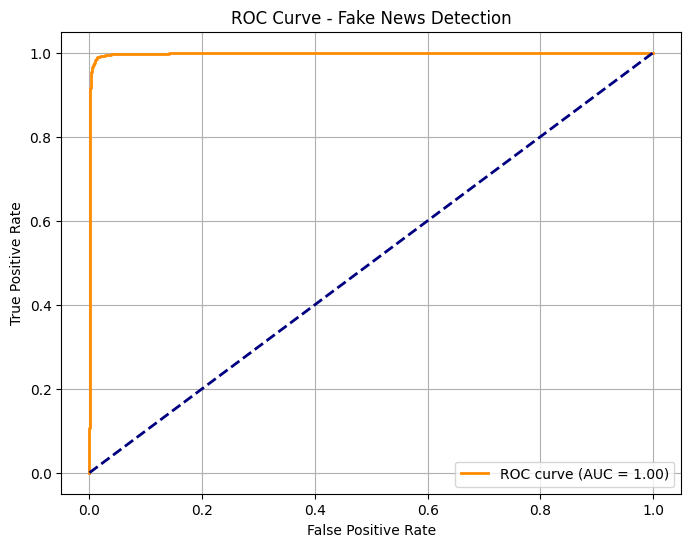

In [14]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize text
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train the model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Get prediction probabilities
y_probs = model.predict_proba(X_test_tfidf)[:, 1]  # Probabilities for class 1 (Fake)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fake News Detection")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Learning-Curve -:-

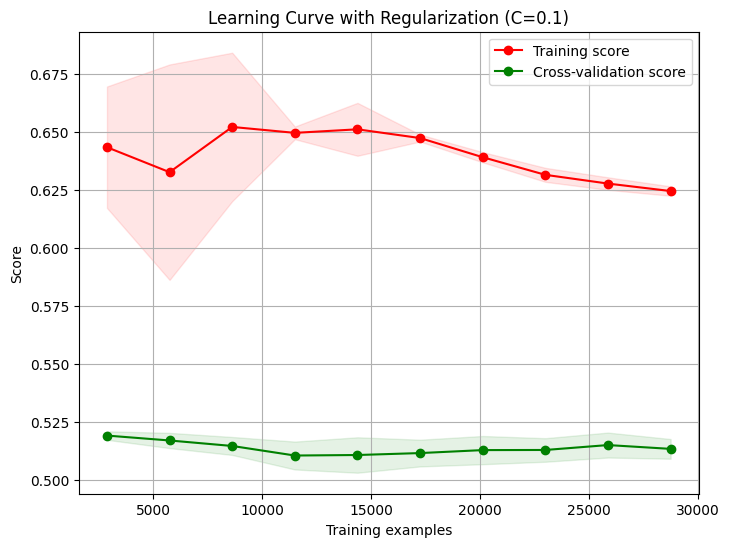

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve

#  Define model with stronger regularization to reduce overfitting
estimator = LogisticRegression(
    C=0.1,            # Smaller C = more regularization
    penalty="l2",     # L2 regularization
    max_iter=1000,
    solver="liblinear"
)

#  Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator,
    tfidf_train,
    y_train,
    cv=5,                             # 5-fold cross-validation
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)   # Training sizes from 10% to 100%
)

#  Calculate mean and std deviation of scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#  Plot Learning Curve
plt.figure(figsize=(8, 6))

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.1,
    color="r"
)
plt.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.1,
    color="g"
)

plt.plot(
    train_sizes,
    train_scores_mean,
    'o-',
    color="r",
    label="Training score"
)
plt.plot(
    train_sizes,
    test_scores_mean,
    'o-',
    color="g",
    label="Cross-validation score"
)

plt.title("Learning Curve with Regularization (C=0.1)")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Best Model Choose -:-

#### Comparative Analysis
##### Calculate Evaluation matrices(Accuracy, precision, f1-score, AUC) of all trained models 
#### Hyperparameter Tuning
##### Find Best parameters of the model by using GridSearchCV, RandomizedSearchCV
#### Cross-Validation
##### Check robustness of model performance - KFold, StratifiedKfold
#### Model Persistence
##### Save Model by using Joblib, pickle like (joblib.dump())

## "Lastly, I want to extend my heartfelt thanks to my Sir, who provided me with excellent AI/ML training, enabling me to build this fake news detection model."